In [111]:
import copy
 
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import tqdm
from sklearn.model_selection import train_test_split

In [108]:
def dataframe_to_sklearn_dataset(df):
    """
    Convert a pandas DataFrame into an sklearn-style regression dataset.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame with x columns:
        - first x-1 columns are features
        - last column is the target

    Returns
    -------
    dict
        sklearn-style dataset dictionary
    """

    feature_names = df.columns[:-1].tolist()
    target_name = df.columns[-1]

    data = df.iloc[:, :-1].to_numpy(dtype=float)
    target = df.iloc[:, -1].to_numpy(dtype=float)

    dataset = {
        "data": data,
        "target": target,
        "frame": None,
        "target_names": [target_name],
        "feature_names": feature_names,
    }

    return dataset

In [109]:
data = pd.read_csv(r'C:\Users\amyry\OneDrive - University of Cambridge\NanoDTC_\Coding\pml_supercond\data\raw\train.csv')
data.head()
data.columns

Index(['number_of_elements', 'mean_atomic_mass', 'wtd_mean_atomic_mass',
       'gmean_atomic_mass', 'wtd_gmean_atomic_mass', 'entropy_atomic_mass',
       'wtd_entropy_atomic_mass', 'range_atomic_mass', 'wtd_range_atomic_mass',
       'std_atomic_mass', 'wtd_std_atomic_mass', 'mean_fie', 'wtd_mean_fie',
       'gmean_fie', 'wtd_gmean_fie', 'entropy_fie', 'wtd_entropy_fie',
       'range_fie', 'wtd_range_fie', 'std_fie', 'wtd_std_fie',
       'mean_atomic_radius', 'wtd_mean_atomic_radius', 'gmean_atomic_radius',
       'wtd_gmean_atomic_radius', 'entropy_atomic_radius',
       'wtd_entropy_atomic_radius', 'range_atomic_radius',
       'wtd_range_atomic_radius', 'std_atomic_radius', 'wtd_std_atomic_radius',
       'mean_Density', 'wtd_mean_Density', 'gmean_Density',
       'wtd_gmean_Density', 'entropy_Density', 'wtd_entropy_Density',
       'range_Density', 'wtd_range_Density', 'std_Density', 'wtd_std_Density',
       'mean_ElectronAffinity', 'wtd_mean_ElectronAffinity',
       'gmean_

In [112]:
#enter parameters to keep here
# this is the top 8 most important features from the XGBoost model 
filtered_params=['range_ThermalConductivity', 'wtd_std_ThermalConductivity', 'range_atomic_radius', 'wtd_gmean_ThermalConductivity','std_ThermalConductivity','wtd_entropy_Valence','wtd_std_ElectronAffinity','wtd_entropy_atomic_mass']
data_filtered = data.filter(items=(filtered_params + ['critical_temp']))
data_filtered.head()

,range_ThermalConductivity,wtd_std_ThermalConductivity,range_atomic_radius,wtd_gmean_ThermalConductivity,std_ThermalConductivity,wtd_entropy_Valence,wtd_std_ElectronAffinity,wtd_entropy_atomic_mass,critical_temp
0,399.97342,138.517163,205,0.621979,168.854244,1.066221,42.558396,1.062396,29.0
1,429.97342,139.630922,205,0.619735,198.554600,1.047221,41.667621,1.057755,26.0
2,399.97342,138.540613,205,0.619095,168.854244,1.029175,41.639878,0.975980,19.0
3,399.97342,138.528893,205,0.620535,168.854244,1.048834,42.102344,1.022291,22.0
4,399.97342,138.493671,205,0.624878,168.854244,1.096052,43.452059,1.129224,23.0


In [113]:
data_sk = dataframe_to_sklearn_dataset(data_filtered)
print(data_sk)

{'data': array([[399.97342   , 138.51716251, 205.        , ...,   1.06622103,
         42.55839575,   1.06239555],
       [429.97342   , 139.63092237, 205.        , ...,   1.04722137,
         41.6676208 ,   1.05775512],
       [399.97342   , 138.54061274, 205.        , ...,   1.02917469,
         41.6398778 ,   0.97598046],
       ...,
       [ 17.        ,   6.8       ,  29.        , ...,   0.45056121,
         12.96      ,   0.53019754],
       [ 17.        ,   7.86238513,  29.        , ...,   0.57760119,
         14.98478108,   0.64088299],
       [ 78.48      ,  38.25443159,  53.        , ...,   0.97011578,
         87.74050433,   0.89522916]], shape=(21263, 8)), 'target': array([29.  , 26.  , 19.  , ...,  1.98,  1.84, 12.8 ], shape=(21263,)), 'frame': None, 'target_names': ['critical_temp'], 'feature_names': ['range_ThermalConductivity', 'wtd_std_ThermalConductivity', 'range_atomic_radius', 'wtd_gmean_ThermalConductivity', 'std_ThermalConductivity', 'wtd_entropy_Valence', 'wtd_st

In [114]:
# Read data
X, y = data_sk['data'], data_sk['target']

# train-test split for model evaluation
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, shuffle=True)
print(f"Filtered Train Shape: {X_train.shape}") 
print(f"Filtered Test Shape: {X_test.shape}")

# Convert to 2D PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1)


Filtered Train Shape: (14884, 8)
Filtered Test Shape: (6379, 8)


In [ ]:
# Define the model. 8 input parameters
model = nn.Sequential(
    nn.Linear(8, 24),
    nn.ReLU(),
    nn.Linear(24, 12),
    nn.ReLU(),
    nn.Linear(12, 6),
    nn.ReLU(),
    nn.Linear(6, 1)
)

# try 64. try alternative activation functions like not ReLu, could try CNN 

C:\Users\amyry\AppData\Local\Temp\ipykernel_4484\1295152282.py:31: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  bar.set_postfix(mse=float(loss))


Epoch 0: MSE = 549.28
Epoch 1: MSE = 533.42
Epoch 2: MSE = 522.26
Epoch 3: MSE = 511.66
Epoch 4: MSE = 500.81
Epoch 5: MSE = 487.97
Epoch 6: MSE = 473.87
Epoch 7: MSE = 460.98
Epoch 8: MSE = 450.45
Epoch 9: MSE = 442.17
Epoch 10: MSE = 435.60
Epoch 11: MSE = 430.21
Epoch 12: MSE = 425.84
Epoch 13: MSE = 421.90
Epoch 14: MSE = 417.87
Epoch 15: MSE = 413.40
Epoch 16: MSE = 409.40
Epoch 17: MSE = 405.24
Epoch 18: MSE = 401.62
Epoch 19: MSE = 397.81
Epoch 20: MSE = 393.14
Epoch 21: MSE = 388.94
Epoch 22: MSE = 385.15
Epoch 23: MSE = 381.51
Epoch 24: MSE = 377.60
Epoch 25: MSE = 373.00
Epoch 26: MSE = 369.50
Epoch 27: MSE = 365.81
Epoch 28: MSE = 362.11
Epoch 29: MSE = 358.18
Epoch 30: MSE = 355.04
Epoch 31: MSE = 351.76
Epoch 32: MSE = 348.58
Epoch 33: MSE = 345.97
Epoch 34: MSE = 341.94
Epoch 35: MSE = 338.07
Epoch 36: MSE = 335.24
Epoch 37: MSE = 333.16
Epoch 38: MSE = 331.13
Epoch 39: MSE = 329.36
Epoch 40: MSE = 327.55
Epoch 41: MSE = 325.78
Epoch 42: MSE = 323.99
Epoch 43: MSE = 322.4

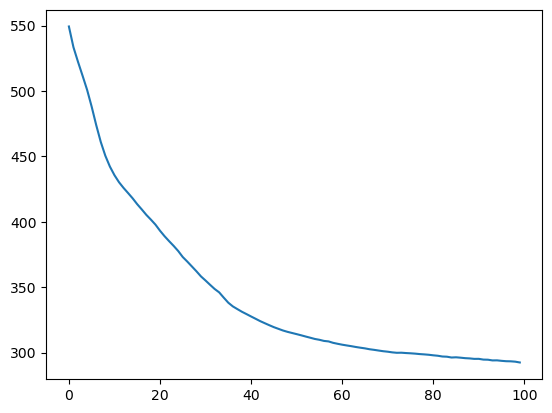

In [8]:
# loss function and optimizer
loss_fn = nn.MSELoss()  # mean square error
optimizer = optim.Adam(model.parameters(), lr=0.0001)
 
n_epochs = 100   # number of epochs to run
batch_size = 10  # size of each batch
batch_start = torch.arange(0, len(X_train), batch_size)
 
# Hold the best model
best_mse = np.inf   # init to infinity
best_weights = None
history = []
 
for epoch in range(n_epochs):
    model.train()
    with tqdm.tqdm(batch_start, unit="batch", mininterval=0, disable=True) as bar:
        bar.set_description(f"Epoch {epoch}")
        for start in bar:
            # take a batch
            X_batch = X_train[start:start+batch_size]
            y_batch = y_train[start:start+batch_size]
            # forward pass
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            # backward pass
            optimizer.zero_grad()
            loss.backward()
            # update weights
            optimizer.step()
            # print progress
            bar.set_postfix(mse=float(loss))
    # evaluate accuracy at end of each epoch
    model.eval()
    y_pred = model(X_test)
    mse = loss_fn(y_pred, y_test)
    mse = float(mse)
    history.append(mse)
    if mse < best_mse:
        best_mse = mse
        best_weights = copy.deepcopy(model.state_dict())
    print(f"Epoch {epoch}: MSE = {mse:.2f}")
 
# restore model and return best accuracy
model.load_state_dict(best_weights)
print("MSE: %.2f" % best_mse)
print("RMSE: %.2f" % np.sqrt(best_mse))
plt.plot(history)
plt.show()

MSE: 292.37

RMSE: 17.10

after 100 epochs


# things this does do
- reduce number of parameters inputted instead of throwing all 81 at it

# things this doesn't do
- any sort of normalisation of inputted data?
- show examples of test predictions vs actual (more visualisation of results than just the loss function)

# with normalisation is below

In [128]:
X_norm = X / X.max(axis=0)
"""print(X)
print(X_norm)
print(X_norm[:,-1])
print(X_norm[:, 0].max())
print(X_norm[:,0].min())
print(X_norm[:,-1].max())
print(X_norm[:,-1].min())"""
y_max = y.max()
y_norm = y / y_max
print(y_max)

# train-test split for model evaluation
X_train, X_test, y_train, y_test = train_test_split(X_norm, y_norm, train_size=0.7, shuffle=True)
print(f"Filtered Train Shape: {X_train.shape}") 
print(f"Filtered Test Shape: {X_test.shape}")

# Convert to 2D PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1)

185.0
Filtered Train Shape: (14884, 8)
Filtered Test Shape: (6379, 8)


In [129]:
# Define the model. 8 input parameters
model = nn.Sequential(
    nn.Linear(8, 24),
    nn.ReLU(),
    nn.Linear(24, 12),
    nn.ReLU(),
    nn.Linear(12, 6),
    nn.ReLU(),
    nn.Linear(6, 1)
)

Epoch 0: MSE = 0.0155 scaled: 530.98
Epoch 1: MSE = 0.0141 scaled: 481.26
Epoch 2: MSE = 0.0132 scaled: 450.76
Epoch 3: MSE = 0.0125 scaled: 428.81
Epoch 4: MSE = 0.0122 scaled: 415.93
Epoch 5: MSE = 0.0119 scaled: 408.04
Epoch 6: MSE = 0.0117 scaled: 402.03
Epoch 7: MSE = 0.0116 scaled: 397.51
Epoch 8: MSE = 0.0115 scaled: 393.76
Epoch 9: MSE = 0.0114 scaled: 390.37
Epoch 10: MSE = 0.0113 scaled: 385.63
Epoch 11: MSE = 0.0111 scaled: 379.24
Epoch 12: MSE = 0.0109 scaled: 374.33
Epoch 13: MSE = 0.0108 scaled: 369.83
Epoch 14: MSE = 0.0107 scaled: 365.21
Epoch 15: MSE = 0.0105 scaled: 360.64
Epoch 16: MSE = 0.0104 scaled: 356.11
Epoch 17: MSE = 0.0103 scaled: 351.73
Epoch 18: MSE = 0.0101 scaled: 347.33
Epoch 19: MSE = 0.0100 scaled: 342.98
Epoch 20: MSE = 0.0099 scaled: 338.76
Epoch 21: MSE = 0.0098 scaled: 334.90
Epoch 22: MSE = 0.0097 scaled: 331.41
Epoch 23: MSE = 0.0096 scaled: 328.03
Epoch 24: MSE = 0.0095 scaled: 324.60
Epoch 25: MSE = 0.0094 scaled: 321.47
Epoch 26: MSE = 0.0093

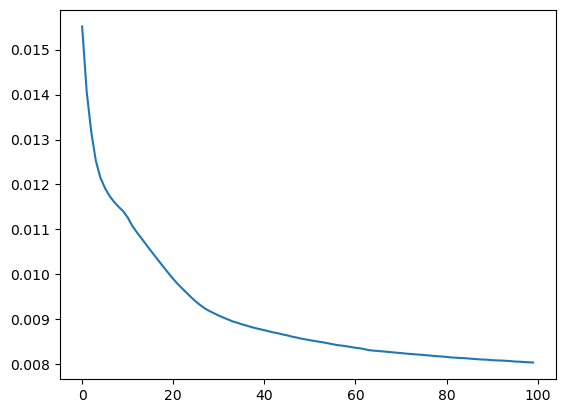

In [130]:
# loss function and optimizer
loss_fn = nn.MSELoss()  # mean square error
optimizer = optim.Adam(model.parameters(), lr=0.0001)
 
n_epochs = 100   # number of epochs to run
batch_size = 10  # size of each batch
batch_start = torch.arange(0, len(X_train), batch_size)
 
# Hold the best model
best_mse = np.inf   # init to infinity
best_weights = None
history = []
 
for epoch in range(n_epochs):
    model.train()
    with tqdm.tqdm(batch_start, unit="batch", mininterval=0, disable=True) as bar:
        bar.set_description(f"Epoch {epoch}")
        for start in bar:
            # take a batch
            X_batch = X_train[start:start+batch_size]
            y_batch = y_train[start:start+batch_size]
            # forward pass
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            # backward pass
            optimizer.zero_grad()
            loss.backward()
            # update weights
            optimizer.step()
            # print progress
            bar.set_postfix(mse=float(loss))
    # evaluate accuracy at end of each epoch
    model.eval()
    y_pred = model(X_test)
    mse = loss_fn(y_pred, y_test)
    mse = float(mse)
    history.append(mse)
    if mse < best_mse:
        best_mse = mse
        best_weights = copy.deepcopy(model.state_dict())
    print(f"Epoch {epoch}: MSE = {mse:.4f}", "scaled: %.2f" % (mse * y_max**2))
 
# restore model and return best accuracy
model.load_state_dict(best_weights)
print("MSE: %.4f " % best_mse, "scaled: %.2f" % (best_mse * y_max**2))
print("RMSE: %.4f " % np.sqrt(best_mse), "scaled: %.2f" % (np.sqrt(best_mse) * y_max))
plt.plot(history)
plt.show()

tensor([[  0.2880],
        [ -5.7413],
        [  0.3022],
        ...,
        [ -2.8096],
        [ -1.6310],
        [-12.4822]], grad_fn=<AddmmBackward0>)


RuntimeError: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.

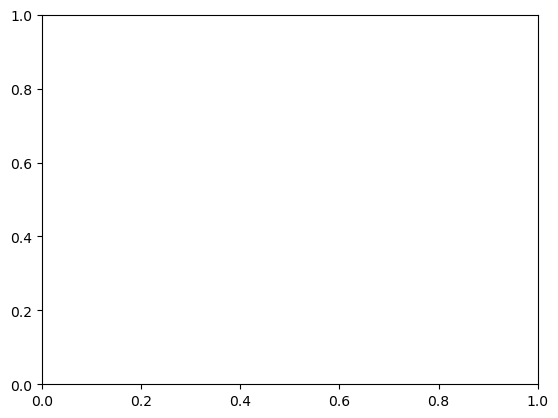

In [131]:
y_predict = model(torch.tensor(X, dtype=torch.float32))
print(y_predict.float())
plt.plot(y, y_predict, '.')


# even larger net

In [132]:
# Define the model. 8 input parameters
model = nn.Sequential(
    nn.Linear(8, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Linear(16, 8),
    nn.ReLU(),
    nn.Linear(8, 1)
)

Epoch 0: MSE = 0.0128 scaled: 437.70
Epoch 1: MSE = 0.0117 scaled: 399.21
Epoch 2: MSE = 0.0113 scaled: 387.35
Epoch 3: MSE = 0.0111 scaled: 379.99
Epoch 4: MSE = 0.0109 scaled: 374.16
Epoch 5: MSE = 0.0108 scaled: 368.67
Epoch 6: MSE = 0.0106 scaled: 363.74
Epoch 7: MSE = 0.0104 scaled: 357.47
Epoch 8: MSE = 0.0103 scaled: 351.63
Epoch 9: MSE = 0.0101 scaled: 346.51
Epoch 10: MSE = 0.0100 scaled: 341.03
Epoch 11: MSE = 0.0098 scaled: 335.84
Epoch 12: MSE = 0.0097 scaled: 331.67
Epoch 13: MSE = 0.0095 scaled: 326.73
Epoch 14: MSE = 0.0094 scaled: 322.56
Epoch 15: MSE = 0.0093 scaled: 318.89
Epoch 16: MSE = 0.0092 scaled: 315.39
Epoch 17: MSE = 0.0091 scaled: 312.30
Epoch 18: MSE = 0.0090 scaled: 309.11
Epoch 19: MSE = 0.0090 scaled: 307.31
Epoch 20: MSE = 0.0089 scaled: 304.17
Epoch 21: MSE = 0.0088 scaled: 301.94
Epoch 22: MSE = 0.0088 scaled: 299.95
Epoch 23: MSE = 0.0087 scaled: 298.17
Epoch 24: MSE = 0.0087 scaled: 296.49
Epoch 25: MSE = 0.0086 scaled: 294.61
Epoch 26: MSE = 0.0086

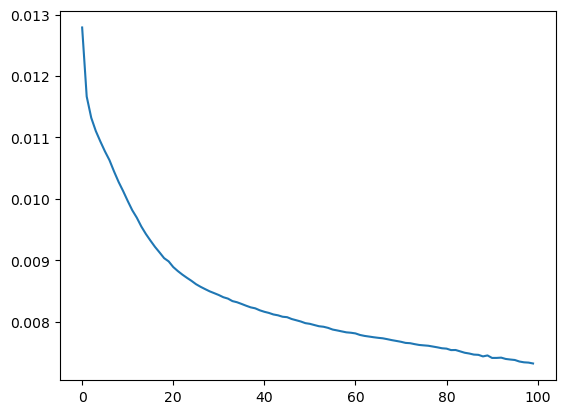

In [133]:
# loss function and optimizer
loss_fn = nn.MSELoss()  # mean square error
optimizer = optim.Adam(model.parameters(), lr=0.0001)
 
n_epochs = 100   # number of epochs to run
batch_size = 10  # size of each batch
batch_start = torch.arange(0, len(X_train), batch_size)
 
# Hold the best model
best_mse = np.inf   # init to infinity
best_weights = None
history = []
 
for epoch in range(n_epochs):
    model.train()
    with tqdm.tqdm(batch_start, unit="batch", mininterval=0, disable=True) as bar:
        bar.set_description(f"Epoch {epoch}")
        for start in bar:
            # take a batch
            X_batch = X_train[start:start+batch_size]
            y_batch = y_train[start:start+batch_size]
            # forward pass
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            # backward pass
            optimizer.zero_grad()
            loss.backward()
            # update weights
            optimizer.step()
            # print progress
            bar.set_postfix(mse=float(loss))
    # evaluate accuracy at end of each epoch
    model.eval()
    y_pred = model(X_test)
    mse = loss_fn(y_pred, y_test)
    mse = float(mse)
    history.append(mse)
    if mse < best_mse:
        best_mse = mse
        best_weights = copy.deepcopy(model.state_dict())
    print(f"Epoch {epoch}: MSE = {mse:.4f}", "scaled: %.2f" % (mse * y_max**2))
 
# restore model and return best accuracy
model.load_state_dict(best_weights)
print("MSE: %.4f " % best_mse, "scaled: %.2f" % (best_mse * y_max**2))
print("RMSE: %.4f " % np.sqrt(best_mse), "scaled: %.2f" % (np.sqrt(best_mse) * y_max))
plt.plot(history)
plt.show()